# AI Forensic Insider Threat Investigator

## Sprint 1 — Data preprocessing, cleaning, and EDA

This sprint loads the CERT r4.2 activity logs, cleans timestamps and employee IDs,
creates daily activity features, and explores activity patterns.

The results are investigation indicators for human review. They do not prove that
an employee is an insider.

### Input files
- logon.csv
- device.csv
- file.csv
- email.csv
- http.csv

In [26]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

## 1. Locate the activity data

The notebook is inside the `notebook` folder. The activity CSV files are in the neighboring `r4.2` folder.

In [27]:
project_dir = Path.cwd()

if project_dir.name == "notebook":
    project_dir = project_dir.parent

data_dir = project_dir / "r4.2"
output_dir = project_dir / "sprint1_output"
output_dir.mkdir(exist_ok=True)

required_files = [
    "logon.csv",
    "device.csv",
    "file.csv",
    "email.csv",
    "http.csv",
]

print("Project folder:", project_dir)
print("Data folder:", data_dir)
print("Output folder:", output_dir)

Project folder: /Users/hrishikeshps/Desktop/Ai-Forensic
Data folder: /Users/hrishikeshps/Desktop/Ai-Forensic/r4.2
Output folder: /Users/hrishikeshps/Desktop/Ai-Forensic/sprint1_output


In [28]:
missing_files = [
    name for name in required_files
    if not (data_dir / name).is_file()
]

if missing_files:
    print("These files are missing:", missing_files)
else:
    print("All five activity files are present.")

All five activity files are present.


## 2. Inspect the source files

I will check the column names and preview a few rows from each file. For the large files, this reads only a small sample.

In [29]:
for filename in required_files:
    file_path = data_dir / filename
    sample = pd.read_csv(file_path, nrows=5)

    print(f"\n{filename}")
    print("Columns:", list(sample.columns))
    display(sample.head(3))


logon.csv
Columns: ['id', 'date', 'user', 'pc', 'activity']


,id,date,user,pc,activity
0,{X1D9-S0ES98JV-5357PWMI},01/02/2010 06:49:00,NGF0157,PC-6056,Logon
1,{G2B3-L6EJ61GT-2222RKSO},01/02/2010 06:50:00,LRR0148,PC-4275,Logon
2,{U6Q3-U0WE70UA-3770UREL},01/02/2010 06:53:04,LRR0148,PC-4124,Logon



device.csv
Columns: ['id', 'date', 'user', 'pc', 'activity']


,id,date,user,pc,activity
0,{J1S3-L9UU75BQ-7790ATPL},01/02/2010 07:21:06,MOH0273,PC-6699,Connect
1,{N7B5-Y7BB27SI-2946PUJK},01/02/2010 07:37:41,MOH0273,PC-6699,Disconnect
2,{U1V9-Z7XT67KV-5649MYHI},01/02/2010 07:59:11,HPH0075,PC-2417,Connect



file.csv
Columns: ['id', 'date', 'user', 'pc', 'filename', 'content']


,id,date,user,pc,filename,content
0,{L9G8-J9QE34VM-2834VDPB},01/02/2010 07:23:14,MOH0273,PC-6699,EYPC9Y08.doc,D0-CF-11-E0-A1-B1-1A-E1 during difficulty over...
1,{H0W6-L4FG38XG-9897XTEN},01/02/2010 07:26:19,MOH0273,PC-6699,N3LTSU3O.pdf,25-50-44-46-2D carpenters 25 landed strait dis...
2,{M3Z0-O2KK89OX-5716MBIM},01/02/2010 08:12:03,HPH0075,PC-2417,D3D3WC9W.doc,D0-CF-11-E0-A1-B1-1A-E1 union 24 declined impo...



email.csv
Columns: ['id', 'date', 'user', 'pc', 'to', 'cc', 'bcc', 'from', 'size', 'attachments', 'content']


,id,date,user,pc,to,cc,bcc,from,size,attachments,content
0,{R3I7-S4TX96FG-8219JWFF},01/02/2010 07:11:45,LAP0338,PC-5758,Dean.Flynn.Hines@dtaa.com;Wade_Harrison@lockhe...,Nathaniel.Hunter.Heath@dtaa.com,NaN,Lynn.Adena.Pratt@dtaa.com,25830,0,middle f2 systems 4 july techniques powerful d...
1,{R0R9-E4GL59IK-2907OSWJ},01/02/2010 07:12:16,MOH0273,PC-6699,Odonnell-Gage@bellsouth.net,NaN,NaN,MOH68@optonline.net,29942,0,the breaking called allied reservations former...
2,{G2B2-A8XY58CP-2847ZJZL},01/02/2010 07:13:00,LAP0338,PC-5758,Penelope_Colon@netzero.com,NaN,NaN,Lynn_A_Pratt@earthlink.net,28780,0,slowly this uncinus winter beneath addition ex...



http.csv
Columns: ['id', 'date', 'user', 'pc', 'url', 'content']


,id,date,user,pc,url,content
0,{V1Y4-S2IR20QU-6154HFXJ},01/02/2010 06:55:16,LRR0148,PC-4275,http://msn.com/The_Human_Centipede_First_Seque...,remain representatives consensus concert altho...
1,{Q5R1-T3EF87UE-2395RWZS},01/02/2010 07:00:13,NGF0157,PC-6056,http://urbanspoon.com/Plunketts_Creek_Loyalsoc...,festival off northwards than congestion partne...
2,{X9O1-O0XW52VO-5806RPHG},01/02/2010 07:03:46,NGF0157,PC-6056,http://aa.com/Rhodocene/rhodocenium/fhaavatqrf...,long away reorganized baldwin seth business 18...


## 3. Clean and preprocess the activity logs

The HTTP log is very large, so I will process every source file in chunks. I will read only the columns needed for Sprint 1, trim employee IDs, parse dates, remove rows with missing IDs or invalid dates, and remove duplicate rows within each chunk.

Each cleaned event will contribute to daily employee activity counts. Message text, URLs, and file contents are not needed for this first analysis, so they will not be included in the output features.

In [30]:
chunk_size = 25_000

def process_activity_file(filename):
    file_path = data_dir / filename
    source = file_path.stem.lower()

    # Read the header first so we can select only useful columns.
    available_columns = pd.read_csv(file_path, nrows=0).columns.tolist()
    available_columns = [column.strip().lower() for column in available_columns]

    useful_columns = ["date", "user", "pc", "activity", "attachments", "filename"]
    columns_to_read = [
        column for column in useful_columns
        if column in available_columns
    ]

    if "date" not in columns_to_read or "user" not in columns_to_read:
        raise ValueError(f"{filename} needs both 'date' and 'user' columns.")

    daily_parts = []
    quality = {
        "rows_read": 0,
        "rows_kept": 0,
        "missing_user": 0,
        "invalid_date": 0,
        "duplicates_removed": 0,
    }

    for chunk in pd.read_csv(
        file_path,
        usecols=lambda column: column.strip().lower() in columns_to_read,
        chunksize=chunk_size,
        low_memory=False,
    ):
        chunk.columns = [column.strip().lower() for column in chunk.columns]
        quality["rows_read"] += len(chunk)

        chunk["user"] = chunk["user"].astype("string").str.strip()
        missing_user = chunk["user"].isna() | chunk["user"].eq("")
        quality["missing_user"] += int(missing_user.sum())

        dates = pd.to_datetime(chunk["date"], errors="coerce", format="mixed")
        invalid_date = dates.isna()
        quality["invalid_date"] += int(invalid_date.sum())

        duplicate = chunk.duplicated()
        quality["duplicates_removed"] += int(duplicate.sum())

        keep = ~(missing_user | invalid_date | duplicate)
        chunk = chunk.loc[keep].copy()
        dates = dates.loc[keep]

        if chunk.empty:
            continue

        quality["rows_kept"] += len(chunk)

        # A row is outside normal working hours if it is before 6 AM
        # or at/after 6 PM, based on the timestamp in the dataset.
        hour = dates.dt.hour
        chunk["after_hours_count"] = (
            (hour < 6) | (hour >= 18)
        ).astype("int8").to_numpy()

        chunk["day"] = dates.dt.strftime("%Y-%m-%d").to_numpy()
        chunk["event_count"] = 1

        feature_columns = ["event_count", "after_hours_count"]

        if source == "device" and "activity" in chunk.columns:
            chunk["device_connect_count"] = (
                chunk["activity"].astype("string").str.lower() == "connect"
            ).astype("int8")
            feature_columns.append("device_connect_count")

        if source == "email" and "attachments" in chunk.columns:
            chunk["attachment_count"] = (
                pd.to_numeric(chunk["attachments"], errors="coerce")
                .fillna(0)
            )
            feature_columns.append("attachment_count")

        group = chunk.groupby(["user", "day"])[feature_columns].sum()
        group = group.rename(
            columns={column: f"{source}_{column}" for column in feature_columns}
        )
        daily_parts.append(group)

    if daily_parts:
        daily_features = (
            pd.concat(daily_parts)
            .groupby(level=["user", "day"])
            .sum()
        )
    else:
        daily_features = pd.DataFrame()

    return daily_features, quality

In [31]:
daily_features_by_source = []
data_quality = {}

for filename in required_files:
    print(f"Processing {filename}...")
    source_features, source_quality = process_activity_file(filename)

    daily_features_by_source.append(source_features)
    data_quality[filename] = source_quality

    print(
        f"  Kept {source_quality['rows_kept']:,} "
        f"of {source_quality['rows_read']:,} rows"
    )

Processing logon.csv...
  Kept 854,859 of 854,859 rows
Processing device.csv...
  Kept 405,374 of 405,380 rows
Processing file.csv...
  Kept 445,581 of 445,581 rows
Processing email.csv...
  Kept 2,618,056 of 2,629,979 rows
Processing http.csv...
  Kept 28,085,484 of 28,434,423 rows


## 4. Combine the cleaned features

The table below has one row for each employee and day. It contains activity counts from the five source files, plus the extra counts available for device connections and email attachments.

In [32]:
employee_daily = pd.concat(daily_features_by_source, axis=1).fillna(0)
employee_daily = employee_daily.groupby(level=["user", "day"]).sum()
employee_daily = employee_daily.reset_index()

employee_daily.head()

,user,day,logon_event_count,logon_after_hours_count,device_event_count,device_after_hours_count,device_device_connect_count,file_event_count,file_after_hours_count,email_event_count,email_after_hours_count,email_attachment_count,http_event_count,http_after_hours_count
0,AAE0190,2010-01-04,2,1,0.0,0.0,0.0,0.0,0.0,14.0,0.0,4.0,143.0,7.0
1,AAE0190,2010-01-05,2,1,0.0,0.0,0.0,0.0,0.0,13.0,0.0,2.0,143.0,1.0
2,AAE0190,2010-01-06,2,1,0.0,0.0,0.0,0.0,0.0,14.0,0.0,12.0,143.0,3.0
3,AAE0190,2010-01-07,2,1,0.0,0.0,0.0,0.0,0.0,14.0,0.0,9.0,142.0,8.0
4,AAE0190,2010-01-08,2,1,0.0,0.0,0.0,0.0,0.0,13.0,0.0,10.0,143.0,3.0


In [33]:
features_path = output_dir / "employee_daily_features.csv"
quality_path = output_dir / "data_quality_summary.json"

employee_daily.to_csv(features_path, index=False)
quality_path.write_text(
    json.dumps(data_quality, indent=2),
    encoding="utf-8",
)

print("Saved cleaned features to:", features_path)
print("Saved data-quality summary to:", quality_path)
print("Employee-day rows:", f"{len(employee_daily):,}")
print("Employees:", f"{employee_daily['user'].nunique():,}")

Saved cleaned features to: /Users/hrishikeshps/Desktop/Ai-Forensic/sprint1_output/employee_daily_features.csv
Saved data-quality summary to: /Users/hrishikeshps/Desktop/Ai-Forensic/sprint1_output/data_quality_summary.json
Employee-day rows: 330,452
Employees: 1,000


## 5. Exploratory data analysis (EDA)

I will compare event volumes across activity sources and look at how total activity changes over time. These charts help describe the dataset; they do not identify an insider by themselves.

,event_count
http_event_count,28085484.0
email_event_count,2618056.0
logon_event_count,854859.0
file_event_count,445581.0
device_event_count,405374.0


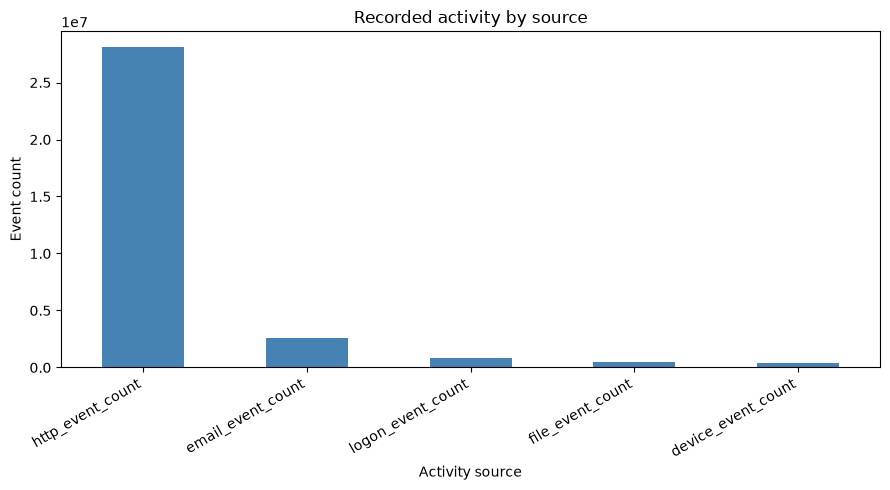

In [34]:
event_columns = [
    column for column in employee_daily.columns
    if column.endswith("_event_count")
]

events_by_source = employee_daily[event_columns].sum().sort_values(
    ascending=False
)

display(events_by_source.to_frame("event_count"))

events_by_source.plot(
    kind="bar",
    figsize=(9, 5),
    title="Recorded activity by source",
    ylabel="Event count",
    xlabel="Activity source",
    color="steelblue",
)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

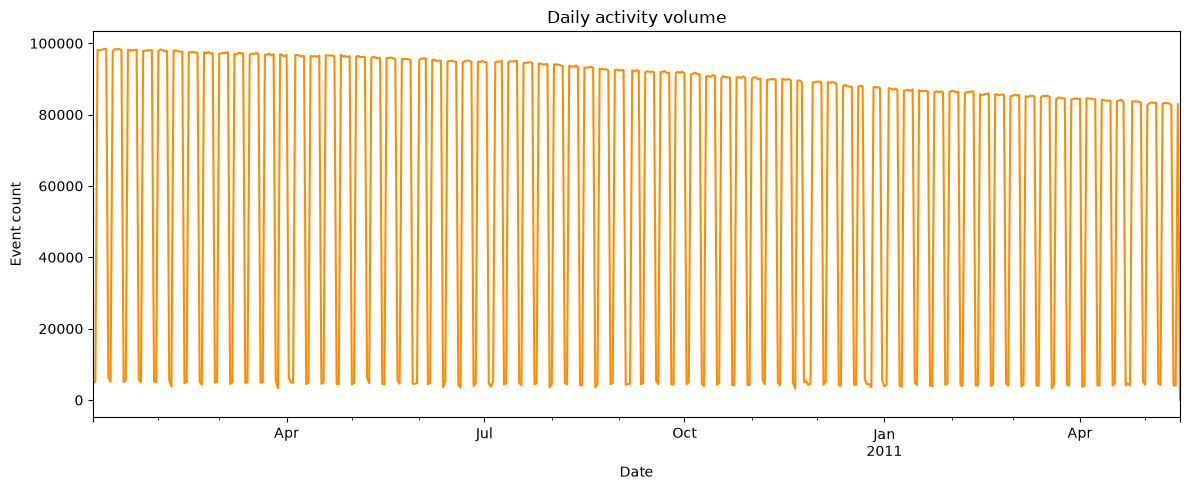

In [35]:
employee_daily["day"] = pd.to_datetime(employee_daily["day"])

daily_event_totals = (
    employee_daily.groupby("day")[event_columns]
    .sum()
    .sum(axis=1)
)

daily_event_totals.plot(
    figsize=(12, 5),
    title="Daily activity volume",
    ylabel="Event count",
    xlabel="Date",
    color="darkorange",
)

plt.tight_layout()
plt.show()

,event_count
user,
MSS0001,143610.0
HCS0003,110774.0
KBP0008,110577.0
DLM0051,108165.0
BTW0005,105826.0
KWC0004,105545.0
HTH0007,105504.0
TVS0006,104426.0
HPH0075,95517.0


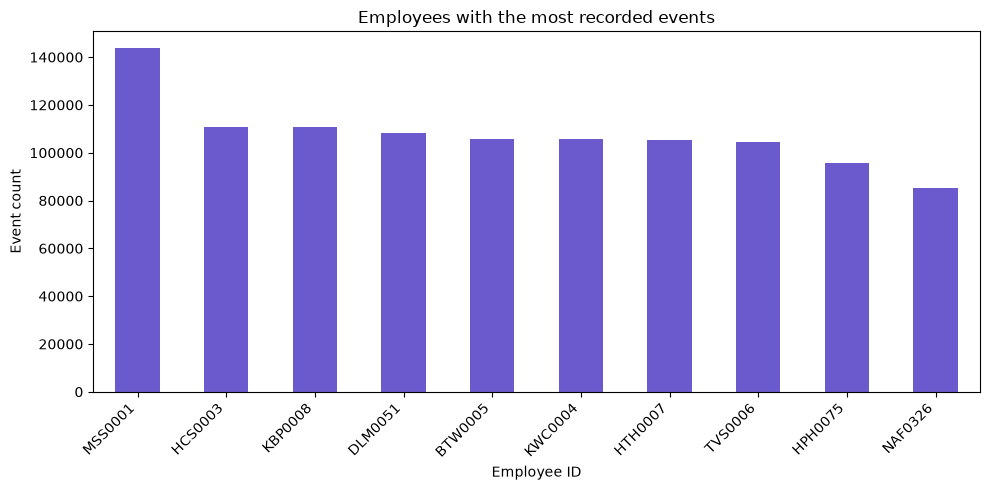

In [36]:
employee_event_totals = (
    employee_daily.groupby("user")[event_columns]
    .sum()
    .sum(axis=1)
    .sort_values(ascending=False)
)

top_employees = employee_event_totals.head(10).rename("event_count")
display(top_employees.to_frame())

top_employees.plot(
    kind="bar",
    figsize=(10, 5),
    title="Employees with the most recorded events",
    ylabel="Event count",
    xlabel="Employee ID",
    color="slateblue",
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Sprint 1 results

Sprint 1 produces:

- `sprint1_output/employee_daily_features.csv` — cleaned employee-by-day activity features.
- `sprint1_output/data_quality_summary.json` — row counts for each file, including missing IDs, invalid dates, and removed duplicates.
- EDA tables and charts showing activity volume by source, date, and employee.

The results describe activity patterns and support further investigation. High activity or after-hours activity is not proof of wrongdoing.

---

# Sprint 2: Model development and project completion

## 1. Prepare known-incident labels

I will use the 4.2 entries in `answers/insiders.csv` to mark employee-days that fall inside a known incident window. This answer file is for model training and evaluation only; it will not be part of the dashboard's uploaded activity data.

A label of 1 means the employee-day overlaps a listed incident. A label of 0 means it is not listed as part of one of those incident windows; it does not prove the activity was normal.

In [37]:
answers_file = project_dir / "answers" / "insiders.csv"

incidents = pd.read_csv(answers_file)

incidents = incidents[incidents["dataset"].astype(str) == "4.2"].copy()

incidents["start"] = pd.to_datetime(
    incidents["start"],
    format="%m/%d/%Y %H:%M:%S",
    errors="coerce",
)

incidents["end"] = pd.to_datetime(
    incidents["end"],
    format="%m/%d/%Y %H:%M:%S",
    errors="coerce",
)

incidents = incidents.dropna(subset=["start", "end"])
incidents.head()

,dataset,scenario,details,user,start,end
8,4.2,1,r4.2-1-AAM0658.csv,AAM0658,2010-10-23 01:34:19,2010-10-29 05:23:28
9,4.2,1,r4.2-1-AJR0932.csv,AJR0932,2010-09-10 19:12:01,2010-09-18 02:02:51
10,4.2,1,r4.2-1-BDV0168.csv,BDV0168,2010-07-30 19:56:44,2010-08-10 05:16:41
11,4.2,1,r4.2-1-BIH0745.csv,BIH0745,2010-07-13 20:15:23,2010-07-13 21:20:44
12,4.2,1,r4.2-1-BLS0678.csv,BLS0678,2010-09-21 01:16:22,2010-09-30 04:48:19


In [38]:
employee_daily["day"] = pd.to_datetime(employee_daily["day"]).dt.normalize()

employee_daily["known_incident_window"] = 0
employee_daily["scenario"] = "not_listed"

for incident in incidents.itertuples(index=False):
    start_day = incident.start.normalize()
    end_day = incident.end.normalize()

    in_incident_window = (
        employee_daily["user"].eq(incident.user)
        & employee_daily["day"].between(start_day, end_day)
    )

    employee_daily.loc[in_incident_window, "known_incident_window"] = 1
    employee_daily.loc[in_incident_window, "scenario"] = str(incident.scenario)

print("Known incident cases:", len(incidents))
print("Employee-days:", len(employee_daily))
print(
    "Employee-days inside known incident windows:",
    int(employee_daily["known_incident_window"].sum()),
)

Known incident cases: 70
Employee-days: 330452
Employee-days inside known incident windows: 1364


In [39]:
label_counts = employee_daily["known_incident_window"].value_counts().sort_index()
label_counts.index = ["Not listed in incident windows", "Inside incident window"]
display(label_counts.to_frame("employee_day_count"))

labeled_file = output_dir / "employee_daily_labeled.csv"
employee_daily.to_csv(labeled_file, index=False)

print("Saved labeled employee-days to:", labeled_file)

,employee_day_count
Not listed in incident windows,329088
Inside incident window,1364


Saved labeled employee-days to: /Users/hrishikeshps/Desktop/Ai-Forensic/sprint1_output/employee_daily_labeled.csv


## 2. Train and compare the models

I will compare Isolation Forest, Logistic Regression, Decision Tree, and Random Forest using the same employee-day features.

I will keep each employee in only one data split, so days from the same employee cannot appear in both training and evaluation data. Model scores are investigation leads, not proof of wrongdoing.

In [40]:
import numpy as np

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

In [41]:
target_column = "known_incident_window"

# Do not let employee IDs, dates, scenarios, or the answer label become model inputs.
excluded_columns = {
    "user",
    "day",
    "scenario",
    target_column,
}

feature_columns = [
    column for column in employee_daily.select_dtypes(include="number").columns
    if column not in excluded_columns
]

X = employee_daily[feature_columns].fillna(0)
y = employee_daily[target_column].astype(int)
groups = employee_daily["user"]

print("Features:", feature_columns)
print("Employee-days:", len(employee_daily))
print("Incident-window labels:", int(y.sum()))

splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

train_indices, test_indices = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_indices]
X_test = X.iloc[test_indices]
y_train = y.iloc[train_indices]
y_test = y.iloc[test_indices]

train_users = set(groups.iloc[train_indices])
test_users = set(groups.iloc[test_indices])

print("Training employees:", len(train_users))
print("Evaluation employees:", len(test_users))
print("Training positive employee-days:", int(y_train.sum()))
print("Evaluation positive employee-days:", int(y_test.sum()))
print("Employees appearing in both splits:", len(train_users & test_users))

Features: ['logon_event_count', 'logon_after_hours_count', 'device_event_count', 'device_after_hours_count', 'device_device_connect_count', 'file_event_count', 'file_after_hours_count', 'email_event_count', 'email_after_hours_count', 'email_attachment_count', 'http_event_count', 'http_after_hours_count']
Employee-days: 330452
Incident-window labels: 1364
Training employees: 800
Evaluation employees: 200
Training positive employee-days: 1075
Evaluation positive employee-days: 289
Employees appearing in both splits: 0


In [42]:
models = {
    "Logistic Regression": make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
        ),
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42,
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42,
    ),

    # This model learns what is unusual without using the incident labels.
    "Isolation Forest": IsolationForest(
        n_estimators=200,
        contamination="auto",
        random_state=42,
        n_jobs=-1,
    ),
}

risk_scores = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

    if name == "Isolation Forest":
        # Larger scores should mean more unusual activity.
        risk_scores[name] = -model.decision_function(X_test)
    else:
        risk_scores[name] = model.predict_proba(X_test)[:, 1]

print("All four models are trained.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Isolation Forest...
All four models are trained.


,Model,Accuracy,Precision,Recall,F1 Score,Average Precision
0,Decision Tree,0.949,0.033,0.377,0.061,0.101
1,Random Forest,0.950,0.042,0.481,0.077,0.068
2,Logistic Regression,0.949,0.033,0.377,0.061,0.025
3,Isolation Forest,0.947,0.017,0.194,0.031,0.024


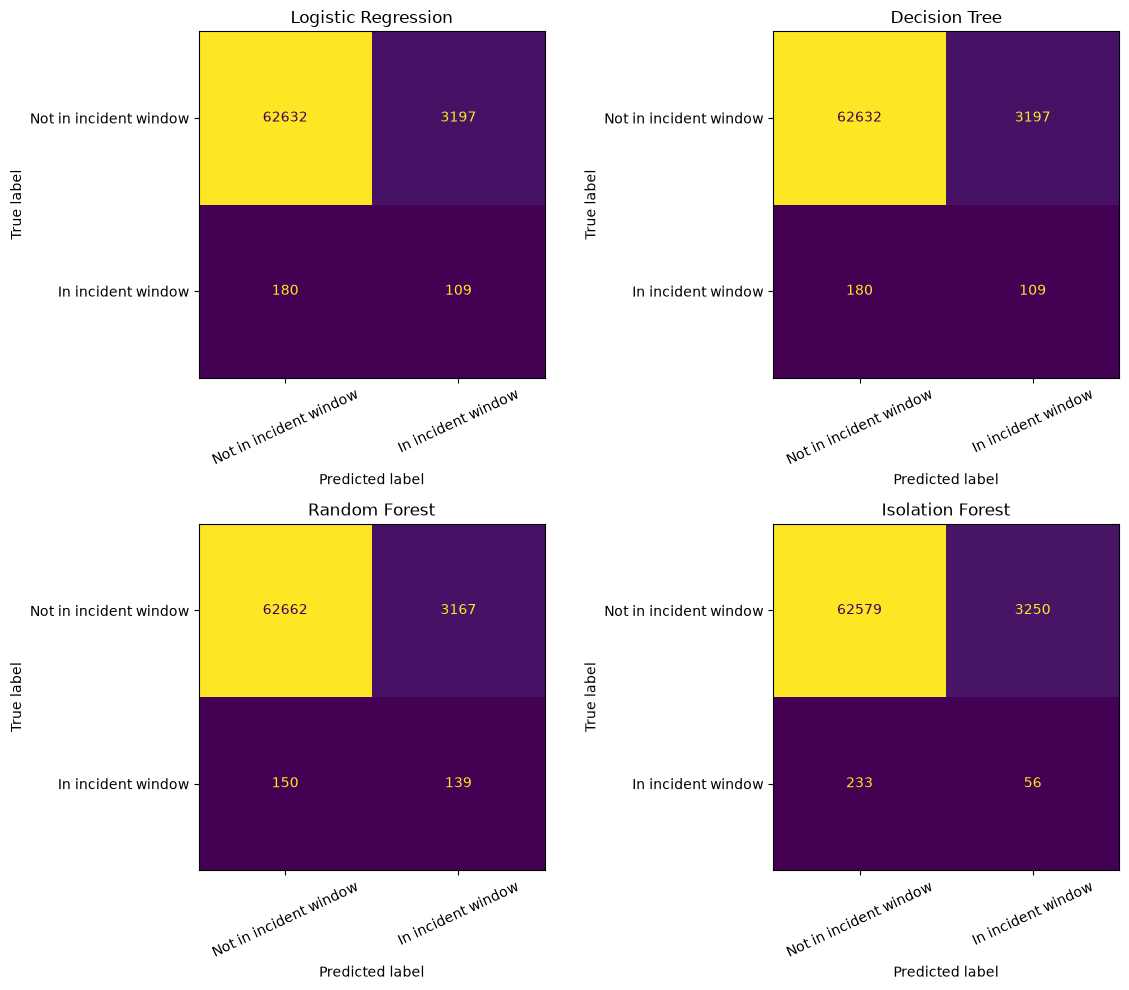

In [43]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
)

results = []
confusion_matrices = {}

actual_labels = y_test.to_numpy()
top_count = max(1, int(np.ceil(len(actual_labels) * 0.05)))

for name, scores in risk_scores.items():
    scores = np.asarray(scores)

    # Flag the same percentage of records for every model.
    top_indices = np.argsort(scores)[-top_count:]
    predicted_labels = np.zeros(len(actual_labels), dtype=int)
    predicted_labels[top_indices] = 1

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(actual_labels, predicted_labels),
        "Precision": precision_score(
            actual_labels, predicted_labels, zero_division=0
        ),
        "Recall": recall_score(
            actual_labels, predicted_labels, zero_division=0
        ),
        "F1 Score": f1_score(
            actual_labels, predicted_labels, zero_division=0
        ),
        "Average Precision": average_precision_score(
            actual_labels, scores
        ),
    })

    confusion_matrices[name] = confusion_matrix(
        actual_labels,
        predicted_labels,
        labels=[0, 1],
    )

model_comparison = (
    pd.DataFrame(results)
    .sort_values("Average Precision", ascending=False)
    .reset_index(drop=True)
)

display(
    model_comparison.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1 Score": "{:.3f}",
        "Average Precision": "{:.3f}",
    })
)

# Show one confusion matrix per model.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, matrix) in zip(axes, confusion_matrices.items()):
    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["Not in incident window", "In incident window"],
    )
    display_matrix.plot(
        ax=ax,
        colorbar=False,
        values_format="d",
    )
    ax.set_title(name)
    ax.tick_params(axis="x", labelrotation=25)

plt.tight_layout()
plt.show()

## 3. Save the evaluation results

I will save the model comparison and the evaluation employee-day scores. The scores help rank records for review; they do not establish that an employee is an insider.

In [44]:
# Save the evaluation table.
comparison_path = output_dir / "model_comparison.csv"
model_comparison.to_csv(comparison_path, index=False)

# Save one row per evaluated employee-day, including each model's score
# and whether it flagged that day in its top 5%.
scored_days = employee_daily.iloc[test_indices][
    ["user", "day", target_column]
].copy().reset_index(drop=True)

actual_labels = y_test.to_numpy()
top_count = max(1, int(np.ceil(len(actual_labels) * 0.05)))

for name, scores in risk_scores.items():
    scores = np.asarray(scores)
    model_column = name.lower().replace(" ", "_")

    scored_days[f"{model_column}_risk"] = scores

    top_indices = np.argsort(scores)[-top_count:]
    flagged = np.zeros(len(scores), dtype=int)
    flagged[top_indices] = 1
    scored_days[f"{model_column}_flagged_top_5_percent"] = flagged

scores_path = output_dir / "evaluation_employee_day_scores.csv"
scored_days.to_csv(scores_path, index=False)

# Save the confusion matrix counts for each model.
confusion_rows = []

for name, matrix in confusion_matrices.items():
    tn, fp, fn, tp = matrix.ravel()
    confusion_rows.append({
        "model": name,
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp,
    })

confusion_path = output_dir / "confusion_matrix_counts.csv"
pd.DataFrame(confusion_rows).to_csv(confusion_path, index=False)

# Rank employees using the model with the highest Average Precision.
best_model = model_comparison.iloc[0]["Model"]
best_risk_column = best_model.lower().replace(" ", "_") + "_risk"

risk_columns = [
    column for column in scored_days.columns
    if column.endswith("_risk")
]

employee_ranking = (
    scored_days.groupby("user")
    .agg({
        **{column: "max" for column in risk_columns},
        target_column: "max",
    })
    .sort_values(best_risk_column, ascending=False)
    .reset_index()
)

ranking_path = output_dir / "evaluation_employee_ranking.csv"
employee_ranking.to_csv(ranking_path, index=False)

print("Saved model comparison:", comparison_path)
print("Saved employee-day scores and flags:", scores_path)
print("Saved confusion matrix counts:", confusion_path)
print("Saved employee ranking:", ranking_path)
print("Ranking uses:", best_model)

Saved model comparison: /Users/hrishikeshps/Desktop/Ai-Forensic/sprint1_output/model_comparison.csv
Saved employee-day scores and flags: /Users/hrishikeshps/Desktop/Ai-Forensic/sprint1_output/evaluation_employee_day_scores.csv
Saved confusion matrix counts: /Users/hrishikeshps/Desktop/Ai-Forensic/sprint1_output/confusion_matrix_counts.csv
Saved employee ranking: /Users/hrishikeshps/Desktop/Ai-Forensic/sprint1_output/evaluation_employee_ranking.csv
Ranking uses: Decision Tree


In [45]:
baseline_rate = float(y_test.mean())

print(f"Positive-label baseline: {baseline_rate:.2%}")

if baseline_rate == 0:
    print("Lift cannot be calculated because the evaluation set has no positive labels.")
else:
    model_comparison["AP lift over baseline"] = (
        model_comparison["Average Precision"] / baseline_rate
    )

    for _, row in model_comparison.iterrows():
        print(
            f"{row['Model']}: "
            f"{row['AP lift over baseline']:.1f}x baseline"
        )

    display(
        model_comparison.style.format({
            "Accuracy": "{:.3f}",
            "Precision": "{:.3f}",
            "Recall": "{:.3f}",
            "F1 Score": "{:.3f}",
            "Average Precision": "{:.3f}",
            "AP lift over baseline": "{:.1f}x",
        })
    )

Positive-label baseline: 0.44%
Decision Tree: 23.1x baseline
Random Forest: 15.7x baseline
Logistic Regression: 5.6x baseline
Isolation Forest: 5.5x baseline


,Model,Accuracy,Precision,Recall,F1 Score,Average Precision,AP lift over baseline
0,Decision Tree,0.949,0.033,0.377,0.061,0.101,23.1x
1,Random Forest,0.950,0.042,0.481,0.077,0.068,15.7x
2,Logistic Regression,0.949,0.033,0.377,0.061,0.025,5.6x
3,Isolation Forest,0.947,0.017,0.194,0.031,0.024,5.5x


## 4. Save all four models for the dashboard

The dashboard needs all four trained models to score new activity data. The three supervised models learn from the known incident labels. Isolation Forest learns patterns of unusual activity without those labels.

After evaluation, I will retrain all four models on the labeled employee-day data and save them together with the feature names. The dashboard can then use their scores to rank employees for review. A suspicious status is a lead for investigation, not proof of wrongdoing.

In [47]:
import joblib

print("Retraining all four models with the labeled employee-day data...")

for name, model in models.items():
    if name == "Isolation Forest":
        # Isolation Forest detects unusual patterns without using the labels.
        model.fit(X)
    else:
        # The other three models learn from the known incident labels.
        model.fit(X, y)

model_bundle = {
    "models": models,
    "feature_columns": feature_columns,
    "model_names": list(models.keys()),
}

model_path = output_dir / "insider_investigation_model.joblib"
joblib.dump(model_bundle, model_path)

print("Saved all four models to:", model_path)
print("Models saved:", ", ".join(model_bundle["model_names"]))

Retraining all four models with the labeled employee-day data...
Saved all four models to: /Users/hrishikeshps/Desktop/Ai-Forensic/sprint1_output/insider_investigation_model.joblib
Models saved: Logistic Regression, Decision Tree, Random Forest, Isolation Forest


In [1]:
from sklearn.metrics import classification_report

print(f"\n{name}")
print(classification_report(
    actual_labels,
    predicted_labels,
    labels=[0, 1],
    target_names=["Not in incident window", "In incident window"],
    zero_division=0,
    digits=3,
))

NameError: name 'name' is not defined